## Training code for CelebA

This notebook provides a comprehensive training and interpretability measures applied to CelebA dataset for the results reported in the paper "Generative adversarial learning can explain why imagination seems less real as we grow up" by Ozsu, Petrova, Dekker & Dijkstra.

It will train models with a simple DCGAN architecture with WGAN-GP, and track the discriminator performance in SDT metrics reported in the paper in Figure 2, 3, 4. To track generator performance it will also calculate FID per epoch reported in Figure 2 and 3. Moreover, it calculates the FID of images that were only marked as real by the discriminator that was reported in Figure 4.

Note that to run this script, you have to download the CelebA dataset from https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html (aligned & cropped). Alternatively, it might be available through Torchvision but you would have to update the code accordingly.

For any questions are if you detect a bug: a.ozsu@ucl.ac.uk


In [ ]:
!nvidia-smi

Tue Feb  3 12:02:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ============================================================================
# IMPORTS
# ============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import os
import pickle
import cv2
import warnings
from timeit import default_timer as timer

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/img_align_celeba.zip" -d "/content"

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """
    Central configuration for all hyperparameters.
    This class holds all the tunable parameters for the GAN, making it easy to
    see and modify the experimental setup from one place.
    """

    # --- 1. Dataset and Data Paths ---
    dataset_name = "celeba"  # Options: 'cifar10', 'mnist'
    data_path = "./data"

    # --- 2. Model Architecture ---
    latent_dim = 100
    generator_feature_maps = 128
    critic_feature_maps = 128
    image_channels = 3

    # --- 3. WGAN-GP Training Parameters ---
    batch_size = 64
    num_epochs = 10
    learning_rate_generator = 0.0001
    learning_rate_critic = 0.0004
    adam_beta1 = 0.0
    adam_beta2 = 0.9
    critic_updates_per_generator_update = 1

    # --- 4. Stability and Regularization ---
    gradient_penalty_weight = 10


    # --- 5. Monitoring, Logging, and Saving ---
    monitor_every_steps = 50
    save_samples_every_steps = 200
    save_model_every_epochs = 5
    save_activations_every_epochs = 1  # Set to 1 to save activations every epoch

    # --- 6. File Paths ---
    local_path = "/content/GAN_Outputs_Final"
    output_dir = os.path.join(local_path, "outputs")
    checkpoint_dir = os.path.join(local_path, "checkpoints")
    activation_dir = os.path.join(local_path, "activations")

    def __init__(self):
        """Creates all necessary output directories to prevent FileNotFoundError."""
        if self.dataset_name == "mnist":
            self.image_channels = 1

        self.samples_dir = os.path.join(self.output_dir, "samples")
        self.monitoring_dir = os.path.join(self.output_dir, "monitoring")
        self.grad_cam_dir = os.path.join(self.output_dir, "grad_cam")

        os.makedirs(self.samples_dir, exist_ok=True)
        os.makedirs(self.monitoring_dir, exist_ok=True)
        os.makedirs(self.grad_cam_dir, exist_ok=True)
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        os.makedirs(self.activation_dir, exist_ok=True)


config = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Outputs will be saved to: {config.local_path}")

Using device: cuda
Outputs will be saved to: /content/GAN_Outputs_Final


In [ ]:
# Delete previous run
! rm -rf /content/GAN_Outputs_Final

In [ ]:
# ============================================================================
# DATASET LOADING
# ============================================================================
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as transforms, datasets
import os

def get_dataloader():
    transform = transforms.Compose(
        [
            transforms.Resize((128,128)),
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5,) * config.image_channels, (0.5,) * config.image_channels
            ),
        ]
    )

    if config.dataset_name == "celeba":
        # Point this to where you put CelebA in your Google Drive
        dataset_root = "/content/img_align_celeba"
        dummy_class = os.path.join(dataset_root, "all")
        os.makedirs(dummy_class, exist_ok=True)
        # Move all images into the dummy subfolder if not already there
        for fname in os.listdir(dataset_root):
            fpath = os.path.join(dataset_root, fname)
            if os.path.isfile(fpath) and (fname.endswith(".jpg") or fname.endswith(".png")):
                os.rename(fpath, os.path.join(dummy_class, fname))
        dataset = ImageFolder(root=dataset_root, transform=transform)
    return DataLoader(
        dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True,
    )

In [ ]:
# ============================================================================
# MODELS (GENERATOR & CRITIC) - Updated for 128x128 Images
# ============================================================================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Input: latent_dim x 1 x 1 -> Output: (gf*16) x 4 x 4
            nn.ConvTranspose2d(
                config.latent_dim,
                config.generator_feature_maps * 16,
                4,
                1,
                0,
                bias=False,
            ),
            nn.BatchNorm2d(config.generator_feature_maps * 16),
            nn.ReLU(True),
            # Input: (gf*16) x 4 x 4 -> Output: (gf*8) x 8 x 8
            nn.ConvTranspose2d(
                config.generator_feature_maps * 16,
                config.generator_feature_maps * 8,
                4,
                2,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(config.generator_feature_maps * 8),
            nn.ReLU(True),
            # Input: (gf*8) x 8 x 8 -> Output: (gf*4) x 16 x 16
            nn.ConvTranspose2d(
                config.generator_feature_maps * 8,
                config.generator_feature_maps * 4,
                4,
                2,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(config.generator_feature_maps * 4),
            nn.ReLU(True),
            # Input: (gf*4) x 16 x 16 -> Output: (gf*2) x 32 x 32
            nn.ConvTranspose2d(
                config.generator_feature_maps * 4,
                config.generator_feature_maps * 2,
                4,
                2,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(config.generator_feature_maps * 2),
            nn.ReLU(True),
            # Input: (gf*2) x 32 x 32 -> Output: gf x 64 x 64
            nn.ConvTranspose2d(
                config.generator_feature_maps * 2,
                config.generator_feature_maps,
                4,
                2,
                1,
                bias=False,
            ),
            nn.BatchNorm2d(config.generator_feature_maps),
            nn.ReLU(True),
            # Input: gf x 64 x 64 -> Output: image_channels x 128 x 128
            nn.ConvTranspose2d(
                config.generator_feature_maps,
                config.image_channels,
                4,
                2,
                1,
                bias=False,
            ),
            nn.Tanh(),
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.orthogonal_(m.weight, gain=0.8)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, z):
        return self.main(z)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: image_channels x 128 x 128 -> Output: cf x 64 x 64
        self.layer1 = nn.Sequential(
            nn.Conv2d(
                config.image_channels, config.critic_feature_maps, 4, 2, 1, bias=False
            ),
            nn.LeakyReLU(0.2, inplace=False),
        )
        # Input: cf x 64 x 64 -> Output: (cf*2) x 32 x 32
        self.layer2 = nn.Sequential(
            nn.Conv2d(
                config.critic_feature_maps,
                config.critic_feature_maps * 2,
                4,
                2,
                1,
                bias=False,
            ),
            nn.InstanceNorm2d(config.critic_feature_maps * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
        )
        # Input: (cf*2) x 32 x 32 -> Output: (cf*4) x 16 x 16
        self.layer3 = nn.Sequential(
            nn.Conv2d(
                config.critic_feature_maps * 2,
                config.critic_feature_maps * 4,
                4,
                2,
                1,
                bias=False,
            ),
            nn.InstanceNorm2d(config.critic_feature_maps * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
        )
        # Input: (cf*4) x 16 x 16 -> Output: (cf*8) x 8 x 8
        self.layer4 = nn.Sequential(
            nn.Conv2d(
                config.critic_feature_maps * 4,
                config.critic_feature_maps * 8,
                4,
                2,
                1,
                bias=False,
            ),
            nn.InstanceNorm2d(config.critic_feature_maps * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
        )
        # Input: (cf*8) x 8 x 8 -> Output: (cf*16) x 4 x 4
        self.layer5 = nn.Sequential(
            nn.Conv2d(
                config.critic_feature_maps * 8,
                config.critic_feature_maps * 16,
                4,
                2,
                1,
                bias=False,
            ),
            nn.InstanceNorm2d(config.critic_feature_maps * 16, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
        )
        # Input: (cf*16) x 4 x 4 -> Output: 1 x 1 x 1
        self.final_conv = nn.Conv2d(
            config.critic_feature_maps * 16, 1, 4, 1, 0, bias=False
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.orthogonal_(m.weight, gain=0.8)
            elif isinstance(m, nn.InstanceNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        h1 = self.layer1(x)
        h2 = self.layer2(h1)
        h3 = self.layer3(h2)
        h4 = self.layer4(h3)
        h5 = self.layer5(h4)
        out = self.final_conv(h5)
        return out.view(-1)

In [ ]:
# ============================================================================
# ANALYSIS TOOLS
# ============================================================================
import os
import numpy as np
import torch
from torchvision.utils import save_image

class ActivationAnalyzer:
    """Collects, analyzes, and saves model activations for offline analysis."""

    def __init__(self, save_dir):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)



def run_grad_cam_analysis(generator, critic, num_images=5, epoch_label="final"):
    """
    Generates images and runs Grad-CAM to visualize what the Critic focuses on.
    This is the definitive, corrected version that resolves the KeyError.
    """
    print("\n--- Running Offline Grad-CAM Analysis ---")
    generator.eval()
    critic.eval()

    # Generate a batch of images up front
    noise = torch.randn(num_images, config.latent_dim, 1, 1, device=device)
    images = generator(noise).detach()
    entropies = []  # store per-image entropy values
    for i in range(num_images):
        image_for_cam = images[i:i+1].clone().requires_grad_(True)
        critic.clear_hooks_data()
        score = critic(image_for_cam)
        score.backward()

        gradients = critic.gradients['layer3'][0]
        activations = critic.activations['layer3'][0]
        pooled_gradients = torch.mean(gradients, dim=[1, 2])
        for j in range(activations.shape[0]):
            activations[j, :, :] *= pooled_gradients[j]

        heatmap = torch.mean(activations, dim=0).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap) if torch.max(heatmap) > 0 else 1.0
        heatmap = heatmap.cpu().detach().numpy()

        # --- Shannon entropy ---
        heatmap_flat = heatmap.flatten()
        if np.var(heatmap_flat) > 1e-6:  # skip nearly flat maps
            hist, _ = np.histogram(heatmap_flat, bins=256, range=(0, 1), density=True)
            hist = hist[hist > 0]
            cam_entropy = entropy(hist, base=2)
            entropies.append(cam_entropy)

        # --- Visualization code ---
        img_np = (image_for_cam[0].permute(1, 2, 0).cpu().detach().numpy() * 0.5) + 0.5
        heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color_rgb = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        superimposed_img = heatmap_color_rgb * 0.4 + img_np * 255 * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        ax1.imshow(img_np); ax1.set_title("Generated Image"); ax1.axis('off')
        ax2.imshow(superimposed_img); ax2.set_title("Grad-CAM Overlay"); ax2.axis('off')

        save_path = os.path.join(config.grad_cam_dir, f"grad_cam_epoch_{epoch_label}_img_{i+1}.png")
        plt.savefig(save_path); plt.close(fig)
        # --- Batch-level summary ---
        if entropies:
            avg_entropy = np.mean(entropies)
            print(f"Epoch {epoch_label}: Average Grad-CAM entropy = {avg_entropy:.4f} (N={len(entropies)} valid maps)")
        else:
            print(f"Epoch {epoch_label}: No valid Grad-CAM maps (all flat/null)")
        print(f"Saved Grad-CAM image to {save_path}")

In [ ]:
# ============================================================================
# TRAINING UTILITIES & MONITORING
# ============================================================================
def get_noise_std(epoch):
    if epoch >= config.noise_decay_epochs:
        return config.final_noise_std
    return config.initial_noise_std * (1.0 - (epoch / config.noise_decay_epochs))


def compute_gradient_penalty(C, real, fake):
    alpha = torch.rand(real.size(0), 1, 1, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    c_interp = C(interp)
    grads = torch.autograd.grad(
        outputs=c_interp,
        inputs=interp,
        grad_outputs=torch.ones(c_interp.size(), device=device),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    return ((grads.view(grads.size(0), -1).norm(2, dim=1) - 1) ** 2).mean()


class GANMonitor:
    def __init__(self):
        self.metrics = defaultdict(lambda: deque(maxlen=1000))
        self.health_scores = []

    def log_step(self, s, e, cl, gl, cr, cf):
        self.metrics["step"].append(s)
        self.metrics["epoch"].append(e)
        self.metrics["c_loss"].append(cl)
        self.metrics["g_loss"].append(gl)
        self.metrics["c_real_score"].append(cr.mean().item())
        self.metrics["c_fake_score"].append(cf.mean().item())

    def check_and_plot_health(self, s):
        if len(self.metrics["c_loss"]) < 10:
            return
        c, g = np.mean(list(self.metrics["c_loss"])[-10:]), np.mean(
            list(self.metrics["g_loss"])[-10:]
        )
        h = 100.0
        if c > 0:
            h -= 30
        if abs(g) > 5 * abs(c) and abs(g) > 10:
            h -= 40
        self.health_scores.append({"step": s, "score": max(0, h)})
        fig, ax = plt.subplots(2, 2, figsize=(15, 10))
        steps = list(self.metrics["step"])
        ax[0, 0].plot(steps, list(self.metrics["c_loss"]), label="Critic")
        ax[0, 0].plot(steps, list(self.metrics["g_loss"]), label="Generator")
        ax[0, 0].set_title("Losses")
        ax[0, 0].legend()
        ax[0, 1].plot(steps, list(self.metrics["c_real_score"]), label="Real")
        ax[0, 1].plot(steps, list(self.metrics["c_fake_score"]), label="Fake")
        ax[0, 1].set_title("Average Scores")
        ax[0, 1].legend()
        if self.health_scores:
            hs = [h["step"] for h in self.health_scores]
            hv = [h["score"] for h in self.health_scores]
            ax[1, 0].plot(hs, hv, color="g")
            ax[1, 0].set_title("Training Health")
            ax[1, 0].set_ylim(0, 100)
        fig.delaxes(ax[1, 1])
        plt.suptitle("WGAN Training Monitor")
        plt.tight_layout()
        plt.savefig(f"{config.monitoring_dir}/dashboard_step_{s}.png")
        plt.close()


# ============================================================================
# REVISED REALITY MONITORING METRICS
# ============================================================================
import os, json, csv, torch

class RealityMonitoringMetrics:
    def __init__(self, uncertainty_width_fraction=0.5, margin_fraction=0.1, save_dir=None):
        self.uncertainty_width_fraction = uncertainty_width_fraction
        self.margin_fraction = margin_fraction
        self.save_dir = save_dir
        if self.save_dir is not None:
            os.makedirs(self.save_dir, exist_ok=True)

        # storage for per-batch metrics
        self.epoch_values = {
            "source_confusion": [],
            "false_memory_rate": [],
            "hypercritical_rate": [],
            "d_prime": []
        }

        # store epoch means over training
        self.history = {
            "source_confusion": [],
            "false_memory_rate": [],
            "hypercritical_rate": [],
            "d_prime": []

        }

        self._epoch_counter = 0  # auto-incremented

        # CSV setup if enabled
        if self.save_dir is not None:
            self.csv_path = os.path.join(self.save_dir, "metrics_log.csv")
            if not os.path.exists(self.csv_path):
                with open(self.csv_path, "w", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow([
                        "epoch", "source_confusion", "false_memory_rate",
                        "hypercritical_rate", "d_prime"
                    ])

    def compute_error_patterns(self, real_scores, fake_scores):
        with torch.no_grad():
            mean_real = real_scores.mean()
            mean_fake = fake_scores.mean()
            w_distance = mean_real - mean_fake

            std_real = real_scores.std(unbiased=False)
            std_fake = fake_scores.std(unbiased=False)

            # Compute denominator of d'
            denom = torch.sqrt(0.5 * (std_real**2 + std_fake**2))

            if w_distance <= 1e-6:
                metrics = {
                    "source_confusion": 1.0,
                    "false_memory_rate": (fake_scores >= real_scores.mean()).float().mean().item(),
                    "hypercritical_rate": (real_scores <= fake_scores.mean()).float().mean().item()
                }
            else:
                midpoint = (mean_real + mean_fake) / 2.0
                band_half_width = (w_distance * self.uncertainty_width_fraction) / 2.0
                uncertainty_lower = midpoint - band_half_width
                uncertainty_upper = midpoint + band_half_width
                d_prime = (mean_real - mean_fake) / (denom + 1e-12)
                real_uncertain = (real_scores > uncertainty_lower) & (real_scores < uncertainty_upper)
                fake_uncertain = (fake_scores > uncertainty_lower) & (fake_scores < uncertainty_upper)
                source_confusion = ((real_uncertain.float().mean() + fake_uncertain.float().mean()) / 2).item()

                margin = w_distance * self.margin_fraction
                false_memory_threshold = midpoint
                false_memory_rate = (fake_scores > false_memory_threshold).float().mean().item()

                hypercritical_threshold = midpoint
                hypercritical_rate = (real_scores < hypercritical_threshold).float().mean().item()

                metrics = {
                    "source_confusion": source_confusion,
                    "false_memory_rate": false_memory_rate,
                    "hypercritical_rate": hypercritical_rate,
                    "d_prime": d_prime
                }

        for k in metrics:
            self.epoch_values[k].append(metrics[k])
        return metrics

    def finalize_epoch(self):
        epoch_means = {k: float(torch.tensor(v).mean().item() if len(v) > 0 else float('nan'))
                       for k, v in self.epoch_values.items()}

        fa = epoch_means["false_memory_rate"]
        miss = epoch_means["hypercritical_rate"]
        d_prime = epoch_means["d_prime"]

        self.history["source_confusion"].append(epoch_means["source_confusion"])
        self.history["false_memory_rate"].append(fa)
        self.history["hypercritical_rate"].append(miss)
        self.history["d_prime"].append(d_prime)


        record = {
            "epoch": self._epoch_counter + 1,
            "source_confusion": epoch_means["source_confusion"],
            "false_memory_rate": fa,
            "hypercritical_rate": miss,
            "d_prime": d_prime,
        }

        if self.save_dir is not None:
            # JSON
            fname = os.path.join(self.save_dir, f"sdt_epoch_{self._epoch_counter + 1:04d}.json")
            with open(fname, "w") as f:
                json.dump(record, f, indent=2)

            # CSV append
            with open(self.csv_path, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    record["epoch"], record["source_confusion"], record["false_memory_rate"],
                    record["hypercritical_rate"], record["d_prime"]
                ])

        for k in self.epoch_values:
            self.epoch_values[k].clear()

        self._epoch_counter += 1
        return record

    def plot_history(self):
      """Plots the developmental trend of each metric so far."""
      plt.figure(figsize=(8, 5))
      for metric_name, values in self.history.items():
          if values:  # skip empty lists
              plt.plot(range(1, len(values) + 1), values, label=metric_name)
      plt.xlabel("Epoch")
      plt.ylabel("Value")
      plt.title("Reality Monitoring Metrics Over Time")
      plt.legend()
      plt.grid(True)
      plt.show()

    def finalize_step(self, step):
        step_means = {k: float(torch.tensor(v).mean().item() if len(v) > 0 else float('nan'))
                      for k, v in self.epoch_values.items()}

        record = {
            "step": step,
            "source_confusion": step_means["source_confusion"],
            "false_memory_rate": step_means["false_memory_rate"],
            "hypercritical_rate": step_means["hypercritical_rate"],
            "d_prime": step_means["d_prime"],
        }

        if self.save_dir is not None:
            # JSON per step
            fname = os.path.join(self.save_dir, f"sdt_step_{step:07d}.json")
            with open(fname, "w") as f:
                json.dump(record, f, indent=2)

            # CSV append
            with open(self.csv_path, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    record["step"], record["source_confusion"], record["false_memory_rate"],
                    record["hypercritical_rate"], record["d_prime"]
                ])

        return record



In [ ]:
# ============================================================================
# MAIN TRAINING LOOP
# ============================================================================
def train():
    from google.colab import files
    import os
    import gc

    dataloader = get_dataloader()
    G = Generator().to(device)
    C = Critic().to(device)
    opt_G = torch.optim.Adam(
        G.parameters(),
        lr=config.learning_rate_generator,
        betas=(config.adam_beta1, config.adam_beta2),
    )
    opt_C = torch.optim.Adam(
        C.parameters(),
        lr=config.learning_rate_critic,
        betas=(config.adam_beta1, config.adam_beta2),
    )
    analyzer = ActivationAnalyzer(save_dir=config.activation_dir)
    monitor = GANMonitor()
    rm_metrics = RealityMonitoringMetrics(save_dir="metrics")
    fixed_noise = torch.randn(64, config.latent_dim, 1, 1, device=device)
    global_step = 0

    print("--- Starting WGAN-GP Training ---")
    for epoch in range(config.num_epochs):
        epoch_start = timer()
        for batch_idx, (real_imgs, _) in enumerate(dataloader):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            for _ in range(config.critic_updates_per_generator_update):
                C.zero_grad()
                z = torch.randn(batch_size, config.latent_dim, 1, 1, device=device)
                fake_imgs = G(z).detach()

                c_real = C(real_imgs)
                c_fake = C(fake_imgs)

                if global_step % config.monitor_every_steps == 0:
                  # Compute metrics on noised images
                  with torch.no_grad():

                      errors = rm_metrics.compute_error_patterns(c_real, c_fake)

                  w_distance = c_real.mean().item() - c_fake.mean().item()

                gp = compute_gradient_penalty(C, real_imgs, fake_imgs)
                loss_C = (
                    c_fake.mean() - c_real.mean() + config.gradient_penalty_weight * gp
                )
                loss_C.backward()
                opt_C.step()

            G.zero_grad()
            z = torch.randn(batch_size, config.latent_dim, 1, 1, device=device)
            gen_imgs = G(z)
            c_gen_fake = C(gen_imgs)
            loss_G = -c_gen_fake.mean()
            loss_G.backward()
            opt_G.step()

            if global_step % config.monitor_every_steps == 0:
                log_message = (
                      f"[{epoch+1:02d}/{config.num_epochs}][{global_step:05d}] | "
                      f"Critic Loss: {loss_C.item():+7.3f} | Gen Loss: {loss_G.item():+7.3f} | "
                      f"Scores (Real/Fake): {c_real.mean().item():+6.2f}/{c_fake.mean().item():+6.2f} | "
                      f"RM (Conf/FM): {errors['source_confusion']:.3f}/{errors['false_memory_rate']:.3f} | "
                      f"W-Distance: {w_distance:.2f}"
                  )
                print(log_message)
                monitor.log_step(global_step, epoch, loss_C.item(), loss_G.item(),
                  c_real.detach().cpu(), c_fake.detach().cpu())
                monitor.check_and_plot_health(global_step)

            if global_step % config.save_samples_every_steps == 0:
                with torch.no_grad():
                    G.eval()
                    save_image(
                        G(fixed_noise),
                        f"{config.samples_dir}/s_{global_step}.png",
                        normalize=True,
                        nrow=8,
                    )
                    G.train()
            global_step += 1


        torch.save(G.state_dict(), f"{config.checkpoint_dir}/G_epoch_{epoch+1}.pth")
        torch.save(C.state_dict(), f"{config.checkpoint_dir}/C_epoch_{epoch+1}.pth")
        print(f"\nSaved models at epoch {epoch+1}\n")

        results = rm_metrics.finalize_epoch()
        print(f"Epoch {epoch+1} metrics:", results)
        print(f"Epoch {epoch+1} finished in {timer() - epoch_start:.2f}s.")

        if (epoch + 1) % 25 == 0:
          rm_metrics.plot_history()

        gc.collect()
        torch.cuda.empty_cache()  # if using GPU
    print("--- Training Completed ---")

    print("\nZipping output files for download...")
    output_folder_name = os.path.basename(config.local_path)
    zip_file_name = f"{output_folder_name}.zip"

    # Zip the folder
    !zip -r "{zip_file_name}" "{output_folder_name}"

    print(f"Done! Downloading '{zip_file_name}'...")

    # Automatically download the zip file
    files.download(zip_file_name)

    !zip -r "metrics.zip" "/content/metrics"

    files.download("metrics.zip")

## How to Read the Live Training Logs

When you run the script, a log entry will be printed periodically. This is your primary window into the health and progress of the GAN training. Here's a sample log and a breakdown of what each value means:

**Sample Log:**
`[05/25][03900] | Critic Loss:  -2.510 | Gen Loss: -15.823 | Scores (Real/Fake): +16.20/-15.11 | RM (Conf/FM): 0.045/0.250`

---

### Legend

| Header | What it Measures | Healthy Trend | Red Flag / Sign of Trouble |
| :--- | :--- | :--- | :--- |
| **`[Epoch/Total][Step]`** | Your current position in the training. | N/A | N/A |
| **`Critic Loss`** | The Wasserstein "distance" between real and fake data distributions. | Should be **negative**. Starts near 0, becomes more negative, then trends back toward 0 late in training as the generator improves. | A consistently **positive** value indicates critic failure. Wild oscillations are a sign of instability. |
| **`Gen Loss`** | The generator's ability to fool the critic. It aims to make this as negative as possible. | Should be **negative**. Becomes more negative as the generator improves at fooling the critic. | Stuck near 0 or becomes positive. This means the generator is not learning. |
| **`Scores (Real/Fake)`** | The average raw score the critic gives to real and fake images. The most intuitive metric. | A **widening gap**. The `Real` score should become positive, and the `Fake` score should become negative. Late in training, the `Fake` score should rise back towards the `Real` score. | No gap forms (stuck at 0). The gap collapses or reverses (`Fake` > `Real`). `Real` score is consistently negative. |
| **`RM (Conf/FM)`** | **R**eality **M**onitoring cognitive metrics. | **Conf** (Confusion) may be high at the start/end. **FM** (False Memory) should start at 0 and **rise late in training**. A high FM rate is a sign of a successful generator. | A high **FM** rate early in training indicates critic failure. An **FM** rate stuck at 0 means the generator is never good enough to fool the critic. |

---

## Configuration Guide (`Config` Class)

All tunable parameters for the experiment are located in the `Config` class. Modifying these values is the primary way to tune the model's performance and behavior.

### 1. Dataset and Data Paths

| Variable | Default | Description |
| :--- | :--- | :--- |
| `dataset_name` | `'cifar10'` | Determines which dataset to load. Options: `'cifar10'`, `'mnist'`. |
| `data_path` | `'./data'` | Directory where the script will download and store datasets. |

### 2. Model Architecture

These parameters define the size and complexity of the neural networks.

| Variable | Default | Impact of Changing |
| :--- | :--- | :--- |
| `latent_dim` | `100` | The size of the random noise vector given to the generator. **Increasing** this (e.g., to 128 or 256) can allow for more complex and diverse generated images, but may also make training slightly harder. |
| `generator_feature_maps` | `64` | The base number of filters in the generator's convolutional layers. **Increasing** this (e.g., to 128) increases the generator's "capacity," allowing it to create more detailed images, but at the cost of memory and computation time. |
| `critic_feature_maps` | `64` | The base number of filters in the critic's layers. **Increasing** this makes the critic more powerful and better at spotting fakes, but can make it harder for the generator to keep up. |
| `image_channels` | `3` | The number of color channels in the images (3 for RGB, 1 for grayscale). This is set automatically based on `dataset_name`. |

### 3. WGAN-GP Training Parameters

These control the core optimization process. They are critical for balancing the "game" between the generator and the critic.

| Variable | Default | Impact of Changing |
| :--- | :--- | :--- |
| `batch_size` | `64` | Number of images per training step. **Increasing** this provides more stable gradients but requires more GPU memory. **Decreasing** it can introduce noise into training but saves memory. |
| `num_epochs` | `25` | Total number of passes over the entire dataset. **Increase** this for a full training run (e.g., to 100, 200, or more) to allow the model to fully converge. |
| `learning_rate_generator` | `0.0001` | How quickly the generator adapts. A **higher** value can speed up learning but risks instability. A **lower** value is safer but slower. |
| `learning_rate_critic` | `0.0002` | How quickly the critic adapts. **It's crucial for this to be well-balanced with the generator's LR.** A common strategy (TTUR) is to make it 2x-4x the generator's LR to ensure the critic provides a strong learning signal. |
| `adam_beta1` | `0.0` | Adam optimizer parameter. `0.0` or `0.5` is often recommended for GANs over the default of `0.9` as it can help prevent training oscillations. |
| `critic_updates_per_generator_update` | `1` | The `n_critic` ratio. A value of `1` means a 1:1 update schedule. **Increasing** this (e.g., to 5) gives the critic much more power, which can be useful if the generator is "winning" too easily, but can also cause instability. |

### 4. Stability and Regularization

These are special techniques to keep the training process from failing.

| Variable | Default | Impact of Changing |
| :--- | :--- | :--- |
| `gradient_penalty_weight` | `5` | The `lambda` value for the WGAN-GP loss. This is a crucial regularizer. If training is unstable or the critic loss explodes, **decreasing** this (e.g., to 5 or 2) can help. If the critic isn't learning well, **increasing** it (e.g., to 10) can provide a stronger signal. |
| `gradient_clip_value` | `1.0` | A direct safeguard against exploding gradients. It caps the norm of the gradients. **Decreasing** this (e.g., to 0.5) can help stabilize very volatile training, but setting it too low can hinder learning. `1.0` is a safe, standard value. |
| `initial_noise_std` | `0.2` | The starting amount of noise added to images. This creates a "curriculum" where the initial task is easier. **Increase** this if the model struggles at the very beginning. |
| `noise_decay_epochs` | `15` | How many epochs it takes for the noise to decay to zero. A **longer** decay period gives the model more time on the "easier" curriculum. |

---

In [ ]:
%%time
train()

100%|██████████| 170M/170M [00:14<00:00, 11.6MB/s]


--- Starting WGAN-GP Training ---


AttributeError: 'Config' object has no attribute 'noise_decay_epochs'

In [ ]:
# ============================================================================
# STEP 1: LOAD THE TRAINED GENERATOR
# ============================================================================

# ============================================================================
# STEP 3: DOWNLOAD AND SAVE REAL CIFAR-10 IMAGES
# ============================================================================
!pip install pytorch-fid

import os
import torch
from torchvision.utils import save_image
import shutil
import csv
import numpy as np
from pytorch_fid.fid_score import compute_statistics_of_path, calculate_frechet_distance
from google.colab import files

checkpoint_dir = "/content/all_checkpoints"


real_images_dir = "/content/real_celebA_images"
os.makedirs(real_images_dir, exist_ok=True)

src = "/content/img_align_celeba"

all_images = [f for f in os.listdir(src) if f.endswith((".jpg", ".png"))]
selected = all_images[:50000]

for fname in selected:
    shutil.move(os.path.join(src, fname), os.path.join(real_images_dir, fname))


image_count = len([
    f for f in os.listdir(real_images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Number of images:", image_count)

if image_count == 50000:
    print("✅ Folder contains exactly 50,000 images.")
else:
    print(f"⚠️ Folder contains {image_count} images, not 50,000.")

# --- Settings ---
EPOCH_INTERVAL = 1    # Run FID every 5 epochs
START_EPOCH = 1
END_EPOCH = 51
num_eval_images = 10000  # Standard for FID
fake_images_dir = "/content/generated_images_for_fid"
real_stats_file = "real_stats_celeba.npz"
os.makedirs(fake_images_dir, exist_ok=True)

from pytorch_fid.inception import InceptionV3

# Create the InceptionV3 model with default dims=2048
block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
inception_model = InceptionV3([block_idx]).to(device)

# --- Step 1: Precompute or load real stats ---
if os.path.exists(real_stats_file):
    print(f"Loading cached real stats from {real_stats_file}")
    real_stats = np.load(real_stats_file)
    real_mu, real_sigma = real_stats["mu"], real_stats["sigma"]
else:
    print(f"Computing real stats for {real_images_dir} (this will take a few minutes)...")
    real_mu, real_sigma = compute_statistics_of_path(
        real_images_dir,
        model=inception_model,
        batch_size=128,
        device=device,
        dims=2048
    )
    np.savez(real_stats_file, mu=real_mu, sigma=real_sigma)
    print(f"Saved real stats to {real_stats_file}")

# --- Step 2: Iterate over epochs ---
fid_results = {}

for epoch in range(START_EPOCH, END_EPOCH + 1, EPOCH_INTERVAL):
    print(f"\n==============================")
    print(f"Epoch {epoch}: Loading Generator")
    print(f"==============================")

    # --- Load Generator ---
    try:
        G_eval = Generator().to(device)
        checkpoint_path = os.path.join(checkpoint_dir, f"G_epoch_{epoch}.pth")
        G_eval.load_state_dict(torch.load(checkpoint_path, map_location=device))
        G_eval.eval()
        print("Generator model loaded successfully.")
    except FileNotFoundError:
        print(f"WARNING: Could not load checkpoint for epoch {epoch}. Skipping.")
        continue

    # --- Generate Fake Images ---
    print(f"\n--- Generating {num_eval_images} fake images for epoch {epoch} ---")
    os.makedirs(fake_images_dir, exist_ok=True)

    with torch.no_grad():
        for i in range(0, num_eval_images, config.batch_size):
            noise = torch.randn(config.batch_size, config.latent_dim, 1, 1, device=device)
            fake_imgs = G_eval(noise)
            for j in range(fake_imgs.size(0)):
                current_idx = i + j
                if current_idx >= num_eval_images:
                    break
                save_path = os.path.join(fake_images_dir, f"img_{current_idx}.png")
                save_image(fake_imgs[j], save_path, normalize=True)
            if (i + config.batch_size) % 1000 < config.batch_size:
                print(f"  ... generated {i + config.batch_size} / {num_eval_images} images")

    print("Fake image generation complete.")

    # --- Step 3: Compute FID (only fake stats) ---
    print("\n--- Calculating FID score... ---")
    fake_mu, fake_sigma = compute_statistics_of_path(
        fake_images_dir,
        model=inception_model,
        batch_size=128,
        device=device,
        dims=2048
    )

    fid_value = calculate_frechet_distance(real_mu, real_sigma, fake_mu, fake_sigma)
    fid_results[epoch] = fid_value
    print(f"FID for epoch {epoch}: {fid_value:.4f}")

    # --- Step 4: Clean up generated images ---
    shutil.rmtree(fake_images_dir)

# --- Step 5: Save results to CSV ---
csv_path = "fid_results_withnoise.csv"
with open(csv_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Epoch", "FID"])
    for ep, fid in fid_results.items():
        writer.writerow([ep, fid])

print(f"\nFID results saved to {csv_path}")

files.download(csv_path)

# --- Print summary ---
print("\n==============================")
print("FID Results by Epoch")
print("==============================")
for ep, fid in fid_results.items():
    print(f"Epoch {ep}: FID = {fid:.4f}")



Number of images: 50000
✅ Folder contains exactly 50,000 images.


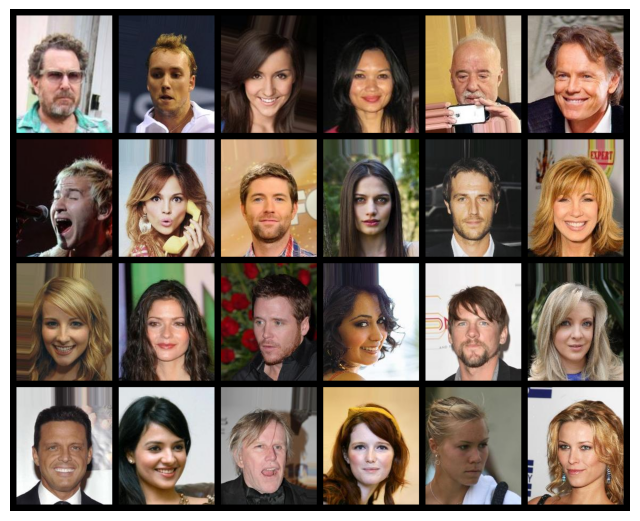

Saved example grid as real_sample_grid.png


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import make_grid, save_image
import torch



# --- Settings ---
real_images_dir = "/content/real_celebA_images"
grid_size = 6  # 8x8 grid → 64 images

# --- List all images ---
all_files = [os.path.join(real_images_dir, f) for f in os.listdir(real_images_dir) if f.endswith(".jpg")]
if len(all_files) < grid_size**2:
    raise ValueError(f"Not enough images in {real_images_dir} to make an 8x8 grid.")

# --- Randomly sample 64 images ---
sampled_files = random.sample(all_files, 24)

# --- Load images and stack them ---
images = [read_image(f).float() / 255.0 for f in sampled_files]  # normalize to [0,1]
images_tensor = torch.stack(images)

# --- Make a grid ---
grid = make_grid(images_tensor, nrow=grid_size, padding=12)

# --- Display the grid ---
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1, 2, 0))  # CHW → HWC for matplotlib
plt.axis("off")
plt.show()

# --- Optional: save the grid ---
save_image(grid, "real_sample_grid.png")
print("Saved example grid as real_sample_grid.png")

In [ ]:
!pip install pytorch_fid
from google.colab import files
import os
import gc
from pytorch_fid.inception import InceptionV3
import numpy as np
from pytorch_fid.fid_score import compute_statistics_of_path, calculate_frechet_distance
from torchvision.utils import save_image, make_grid
import os
import torch
import pandas as pd
import shutil


fake_images_dir = "/content/generated_images_for_fid"
real_stats_file = "real_stats_celeba.npz"


real_images_dir = "/content/real_celebA_images"
os.makedirs(real_images_dir, exist_ok=True)

src = "/content/img_align_celeba"

all_images = [f for f in os.listdir(src) if f.endswith((".jpg", ".png"))]
selected = all_images[:50000]

for fname in selected:
    shutil.move(os.path.join(src, fname), os.path.join(real_images_dir, fname))


image_count = len([
    f for f in os.listdir(real_images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Number of images:", image_count)

if image_count == 50000:
    print("✅ Folder contains exactly 50,000 images.")
else:
    print(f"⚠️ Folder contains {image_count} images, not 50,000.")

# Create the InceptionV3 model with default dims=2048
block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
inception_model = InceptionV3([block_idx]).to(device)

# --- Step 1: Precompute or load real stats ---
if os.path.exists(real_stats_file):
    print(f"Loading cached real stats from {real_stats_file}")
    real_stats = np.load(real_stats_file)
    real_mu, real_sigma = real_stats["mu"], real_stats["sigma"]
else:
    print(f"Computing real stats for {real_images_dir} (this will take a few minutes)...")
    real_mu, real_sigma = compute_statistics_of_path(
        real_images_dir,
        model=inception_model,
        batch_size=128,
        device=device,
        dims=2048
    )

    np.savez(real_stats_file, mu=real_mu, sigma=real_sigma)
    print(f"Saved real stats to {real_stats_file}")

all_fids = []
final_epoch = 51
n_images = 10000
out_dir="fooled_images"
grid_dir="example_grids"
os.makedirs(out_dir, exist_ok=True)
os.makedirs(grid_dir, exist_ok=True)

for iEpoch in range(1, final_epoch):

    epoch_to_analyze = iEpoch
    print(f"Starting epoch {iEpoch}")
    dataloader = get_dataloader()
    G = Generator().to(device)
    C = Critic().to(device)
    checkpoint_dir = "/content/all_checkpoints"
    c_path = os.path.join(checkpoint_dir, f'C_epoch_{epoch_to_analyze}.pth')
    C.load_state_dict(torch.load(c_path))
    G_path = os.path.join(checkpoint_dir, f'G_epoch_{epoch_to_analyze}.pth')
    G.load_state_dict(torch.load(G_path))

    G.eval()
    C.eval()

    saved = 0
    grid_count = 0
    recent_fooled = []

    with torch.no_grad():
        for batch_idx, (real_imgs, _) in enumerate(dataloader):

            if saved >= n_images:
                break
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            z = torch.randn(batch_size, config.latent_dim, 1, 1, device=device)
            fake_imgs = G(z)
            fake_scores = C(fake_imgs).view(-1)
            real_scores = C(real_imgs).view(-1)
            mean_real = real_scores.mean()
            mean_fake = fake_scores.mean()

            threshold = (mean_real + mean_fake) / 2.0

            fooled_mask = fake_scores > threshold
            fooled_imgs = fake_imgs[fooled_mask]

            for img in fooled_imgs:

                if saved >= n_images:
                    break
                save_image(
                    img,
                    os.path.join(out_dir, f"img_{saved:06d}.png"),
                    normalize=True
                )

                recent_fooled.append(img.cpu())
                saved += 1

            # Save a 9x9 grid every ~1000 images
            if saved // 1000 > grid_count and len(recent_fooled) >= 81:
                grid = make_grid(recent_fooled[-81:], nrow=9, normalize=True)
                save_image(
                    grid,
                    os.path.join(grid_dir, f"grid_{grid_count:02d}_epoch{iEpoch}.png")
                )
                grid_count += 1

            print(f"Collected {saved} / {n_images} fooled images")


    print("Done.")

    fake_mu, fake_sigma = compute_statistics_of_path(
    out_dir,
    model=inception_model,
    batch_size=128,
    device=device,
    dims=2048
    )

    fid = calculate_frechet_distance(
    real_mu, real_sigma,
    fake_mu, fake_sigma
    )

    print("FID (fooled images):", fid)

    all_fids.append(fid)

df = pd.DataFrame({
    "epoch": range(1, final_epoch),
    "fid": all_fids})
csv_path = os.path.join(out_dir, "FID_over_epochs.csv")
df.to_csv(csv_path, index=False)
print("✅ Saved accumulated FID results to:", csv_path)





In [ ]:
# ============================================================================
# STEP 4: (OPTIONAL) RE-ZIP RESULTS
# ============================================================================

print("\n\n--- Analysis Complete! Re-zipping all output files. ---")
!zip -r -q "{os.path.basename(config.local_path)}.zip" "{config.local_path}"
print(f"Done! The zip file '{os.path.basename(config.local_path)}.zip' now contains all training and analysis results.")